# 05 — End-to-End: from `midas-calibrate-v2` to `midas-integrate-v2`

**Time: ~15 minutes.** Builds on Notebooks 01 and 03.

## What you'll learn

The `midas` toolkit splits calibration from integration:

- **`midas-calibrate-v2`** — Bayesian calibration framework. Refines
  geometry + 15-parameter distortion + per-ring offsets + thin-plate
  spline residual using all rings of a calibrant frame, returns
  uncertainty estimates (Laplace approximation).
- **`midas-integrate-v2`** — radial integration with the polygon-area
  kernel, soft-binning autograd path, and the loss/refinement
  utilities you saw in notebooks 03-04.

In real beamline use, you calibrate once with calibrate-v2 and then
integrate many sample frames with integrate-v2. This notebook walks
through that handoff.

We'll keep it lightweight by skipping the Bayesian calibration loop
(it has its own notebooks in `midas_calibrate_v2/notebooks/`) and just
constructing a `PVCalibrationResult`-shaped object so you see the
adapter pattern.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd() if Path.cwd().name == "notebooks" else Path("notebooks")
REPO = HERE.resolve().parents[2]
DATA = REPO / "FF_HEDM" / "Example" / "Calibration"

from midas_integrate.params import parse_params, IntegrationParams
from midas_integrate_v2 import (
    spec_from_v1_params,
    SubpixelBinGeometry, integrate_subpixel,
)
from midas_integrate_v2 import v1_params_from_spec
from midas_calibrate_v2.compat.to_integrate import to_integrate_params


## Step 1 — A v2 calibration result is a small Python object

`midas-calibrate-v2` returns a `PVCalibrationResult` (or
`FourStageResult`) with an `.unpacked` dict of refined torch tensors
plus diagnostic info. We mimic this with a stand-in dataclass so this
notebook doesn't require a full Bayesian calibration run (which can
take 5+ minutes).


In [2]:
from dataclasses import dataclass

@dataclass
class FakePVResult:
    """Stand-in for midas_calibrate_v2.PVCalibrationResult."""
    unpacked: dict


# Simulate a calibration that converged on the Pilatus geometry
# (same values as parameters.txt).
calibrated_unpacked = {
    "Lsd":      torch.tensor(657_437.0,    dtype=torch.float64),
    "BC_y":     torch.tensor(685.49,        dtype=torch.float64),
    "BC_z":     torch.tensor(921.03,        dtype=torch.float64),
    "tx":       torch.tensor(0.0,           dtype=torch.float64),
    "ty":       torch.tensor(0.20,          dtype=torch.float64),
    "tz":       torch.tensor(0.45,          dtype=torch.float64),
    "Parallax": torch.tensor(0.0,           dtype=torch.float64),
    "Wavelength": torch.tensor(0.172979,    dtype=torch.float64),
    # v2 distortion names (a few of the 15)
    "iso_R2":   torch.tensor(-5.4e-4,       dtype=torch.float64),
    "iso_R4":   torch.tensor(0.0,           dtype=torch.float64),
    "iso_R6":   torch.tensor(0.0,           dtype=torch.float64),
    "a1":       torch.tensor(0.0,           dtype=torch.float64),
    "phi1":     torch.tensor(0.0,           dtype=torch.float64),
    # ... (the rest default to 0)
}
res = FakePVResult(unpacked=calibrated_unpacked)
print("Calibration result has refined values for: "
      + ", ".join(res.unpacked.keys()))


Calibration result has refined values for: Lsd, BC_y, BC_z, tx, ty, tz, Parallax, Wavelength, iso_R2, iso_R4, iso_R6, a1, phi1


## Step 2 — Bridge: `to_integrate_params`

`midas_calibrate_v2.compat.to_integrate.to_integrate_params` takes a
v2 calibration result + a v1-style template (carrying detector size,
binning, masks, etc.) and produces a ready-to-go
`IntegrationParams` with the v2 distortion names mapped to v1's
`p0..p14` slots.


In [3]:
# Template: detector size, binning, RhoD — anything not refined.
template = parse_params(DATA / "parameters.txt")
template.RBinSize = 2.0      # coarsen for speed in this notebook
template.EtaBinSize = 5.0

ip_v1 = to_integrate_params(res, template=template, warn_on_dropped=False)

print(f"Lsd:    {ip_v1.Lsd:.1f} µm  (from calibration result)")
print(f"BC_y:   {ip_v1.BC_y:.3f} px (from calibration result)")
print(f"ty:     {ip_v1.ty:.3f}°    (from calibration result)")
print(f"p2:     {ip_v1.p2:.6e}     (← iso_R2, name remapped)")
print(f"NrPixelsY: {ip_v1.NrPixelsY} (from template)")
print(f"RBinSize:  {ip_v1.RBinSize} (from template)")


Lsd:    657437.0 µm  (from calibration result)
BC_y:   685.490 px (from calibration result)
ty:     0.200°    (from calibration result)
p2:     -5.400000e-04     (← iso_R2, name remapped)
NrPixelsY: 1475 (from template)
RBinSize:  2.0 (from template)


**The v2 → v1 distortion name remap** is the canonical one used
throughout MIDAS:

```
iso_R2 → p2     iso_R4 → p5     iso_R6 → p4
a1 → p7         phi1 → p8       a2 → p0         phi2 → p6
a3 → p9         phi3 → p10      a4 → p1         phi4 → p3
a5 → p11        phi5 → p12      a6 → p13        phi6 → p14
```

So all v1 consumers (`midas-integrate` CLI, `IntegratorZarrOMP`, the
peak-fit pipeline) see a calibrated `IntegrationParams` they understand.

## Step 3 — From `IntegrationParams` to `IntegrationSpec`

If you want to use the v2 integration features (autograd, polygon-area
kernel, the loss aggregators), convert via `spec_from_v1_params`:


In [4]:
spec = spec_from_v1_params(ip_v1, requires_grad=False)
print(f"IntegrationSpec built: "
      f"{spec.NrPixelsY}×{spec.NrPixelsZ} px, "
      f"Lsd={float(spec.Lsd)/1000:.1f} mm, "
      f"{spec.n_r_bins} R bins × {spec.n_eta_bins} η bins")


IntegrationSpec built: 1475×1679 px, Lsd=657.4 mm, 595 R bins × 72 η bins


## Step 4 — Integrate a sample frame with the calibrated geometry

This is the production workflow: load a sample frame, integrate it
with the calibration you just got from calibrate-v2.


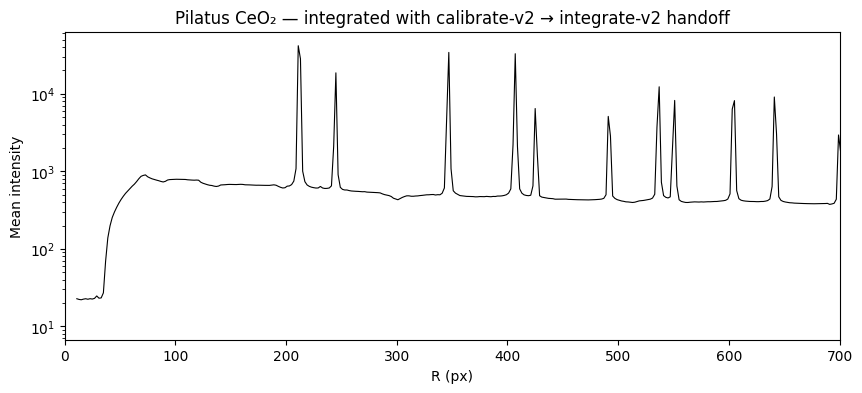

In [5]:
import tifffile
img_raw = tifffile.imread(
    DATA / "CeO2_Pil_100x100_att000_650mm_71p676keV_001956.tif"
).astype(np.float64)
dark = tifffile.imread(
    DATA / "dark_CeO2_Pil_100x100_att000_650mm_71p676keV_001975.tif"
).astype(np.float64)
if dark.ndim == 3:
    dark = dark.mean(axis=0)
img = torch.from_numpy(np.clip(img_raw - dark, 0, None))

geom = SubpixelBinGeometry.from_spec(spec, K=2)
int2d = integrate_subpixel(img, geom, normalize=True)
prof = int2d.mean(dim=0).numpy()

n_r = spec.n_r_bins
r_axis = spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(r_axis, prof, "k-", lw=0.8)
ax.set_xlabel("R (px)"); ax.set_ylabel("Mean intensity")
ax.set_yscale("log"); ax.set_xlim(0, 700)
ax.set_title("Pilatus CeO₂ — integrated with calibrate-v2 → integrate-v2 handoff")
plt.show()


## Recap — the production pipeline

```
calibrant frame  ─→  midas_calibrate_v2.autocalibrate_pv()
                                ↓
                      PVCalibrationResult
                                ↓
            to_integrate_params(res, template)
                                ↓
                       IntegrationParams (v1)
                                ↓
                  spec_from_v1_params(ip)
                                ↓
                       IntegrationSpec (v2)
                                ↓
                  SubpixelBinGeometry.from_spec()
                                ↓
                     integrate_subpixel(image)
                                ↓
                          1-D profile
```

In production, you'd run the calibration *once* per detector setup
(per beamtime, per realignment) and then integrate hundreds or
thousands of sample frames using the same `IntegrationSpec`.

## What about Stage-4 spline + δr_k?

`calibrate-v2` can also fit a thin-plate-spline residual correction
(catches sub-pixel detector pixel-pitch errors) and per-ring radial
offsets `δr_k` (the F2 fix). `to_integrate_params` knows about
these too:

```python
ip_v1 = to_integrate_params(
    res,
    template=template,
    output_dir="./calibration_outputs",     # writes spline + δr_k sidecars
    ring_d_spacing_A=ring_d, ring_two_theta_deg=ring_tt,
)
```

The sidecars are then loaded by integrate-v2 (or by downstream
peak-fit / Rietveld tools).

## Try it yourself

1. **Run a real calibration.** Open a notebook in
   `midas_calibrate_v2/notebooks/` and run the autocalibrate-PV
   pipeline. Then plug the result into the workflow above.
2. **Use the polygon-area kernel.** Replace `SubpixelBinGeometry` /
   `integrate_subpixel` with `PolygonBinGeometry` /
   `integrate_polygon`. Compare the integrated profile — they should
   agree on peak positions to sub-bin precision (the polygon path is
   *exact*, no oversampling artefact).
3. **Integrate a stack of frames.** Load N TIFFs, stack into
   `(N, NrPixelsZ, NrPixelsY)` torch tensor, call
   `integrate_subpixel_batch` (or `_polygon_batch` once that lands).
   Demonstrates that the geometry build is amortised across the batch.

## You're done!

You now know:

- What detector integration is (notebook 01).
- What each calibration parameter physically does (notebook 02).
- How v2's autograd-based joint refinement works (notebook 03).
- How to handle multi-distance calibration (notebook 04).
- How to bridge from `midas-calibrate-v2` to `midas-integrate-v2`
  (this notebook).

The `midas-integrate-v2` README has the full API reference. For deeper
reading, the package has 142+ tests covering edge cases, multi-image
flows, the polygon kernel, and the autograd machinery.
